In [14]:
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt


In [5]:
db_path = Path("../../db/unified_trade_data.duckdb")
conn = duckdb.connect(str(db_path))


In [20]:
tables = conn.execute("SHOW TABLES").fetchall()
print("Таблицы:", tables)


Таблицы: [('country_reference',), ('fizob_index',), ('fizob_index_v',), ('tnved_reference',), ('unified_trade_data',), ('unified_trade_data_enriched',)]


In [21]:
schema = conn.execute("DESCRIBE unified_trade_data").df()
print(schema)


   column_name column_type null   key default extra
0         NAPR     VARCHAR  YES  None    None  None
1       STRANA     VARCHAR  YES  None    None  None
2        TNVED     VARCHAR  YES  None    None  None
3        EDIZM     VARCHAR  YES  None    None  None
4    EDIZM_ISO     VARCHAR  YES  None    None  None
5        STOIM      DOUBLE  YES  None    None  None
6        NETTO      DOUBLE  YES  None    None  None
7          KOL      DOUBLE  YES  None    None  None
8       TNVED4     VARCHAR  YES  None    None  None
9       TNVED6     VARCHAR  YES  None    None  None
10      TNVED2     VARCHAR  YES  None    None  None
11      TNVED8     VARCHAR  YES  None    None  None
12      SOURCE     VARCHAR  YES  None    None  None
13      PERIOD        DATE  YES  None    None  None


In [23]:
top_groups = conn.execute("""
    SELECT 
        TNVED2_NAME,
        SUM(STOIM)/10^9 as total_import,
        COUNT(DISTINCT STRANA) as num_countries
    FROM unified_trade_data_enriched
    WHERE PERIOD >= '2025-01-01' AND NAPR = 'ИМ'
    GROUP BY TNVED2_NAME
    ORDER BY total_import DESC
    LIMIT 10
""").df()

print(top_groups)


                                         TNVED2_NAME  total_import  \
0  РЕАКТОРЫ ЯДЕРНЫЕ, КОТЛЫ, ОБОРУДОВАНИЕ И МЕХАНИ...     31.303706   
1  ЭЛЕКТРИЧЕСКИЕ МАШИНЫ И ОБОРУДОВАНИЕ, ИХ ЧАСТИ;...     17.365366   
2  СРЕДСТВА НАЗЕМНОГО ТРАНСПОРТА, КРОМЕ ЖЕЛЕЗНОДО...     15.222176   
3                         ФАРМАЦЕВТИЧЕСКАЯ ПРОДУКЦИЯ      9.724027   
4  ИНСТРУМЕНТЫ И АППАРАТЫ ОПТИЧЕСКИЕ, ФОТОГРАФИЧЕ...      6.139951   
5                        ПЛАСТМАССЫ И ИЗДЕЛИЯ ИЗ НИХ      5.410108   
6                 ОРГАНИЧЕСКИЕ ХИМИЧЕСКИЕ СОЕДИНЕНИЯ      4.367679   
7              ТОВАРЫ НИЗКОЙ СТОИМОСТИ, ≤ 2000 ЮАНЕЙ      4.103298   
8                         ИЗДЕЛИЯ ИЗ ЧЕРНЫХ МЕТАЛЛОВ      3.405979   
9      ОБУВЬ, ГЕТРЫ И АНАЛОГИЧНЫЕ ИЗДЕЛИЯ; ИХ ДЕТАЛИ      3.374328   

   num_countries  
0             50  
1             47  
2             45  
3             48  
4             53  
5             51  
6             44  
7              2  
8             45  
9             44  


In [8]:
df_old = conn.execute("""
    SELECT * FROM unified_trade_data 
    WHERE PERIOD < '2022-01-01'
    LIMIT 5000
""").df()

print(f"Строк: {len(df_old)}")
print(f"Период: {df_old['PERIOD'].min()} — {df_old['PERIOD'].max()}")
print(f"Страны: {df_old['STRANA'].unique()}")
if 'SOURCE' in df_old.columns:
    print(df_old['SOURCE'].value_counts())


Строк: 5000
Период: 2019-01-01 00:00:00 — 2019-01-01 00:00:00
Страны: ['AD' 'AE' 'AM' 'AO' 'AR' 'AU' 'AZ' 'BA' 'BB' 'BE']
SOURCE
comtrade    5000
Name: count, dtype: int64


In [13]:
top_import_2025 = conn.execute("""
    SELECT STRANA, SUM(STOIM)/10^9 as total_import
    FROM unified_trade_data
    WHERE PERIOD >= '2025-01-01' AND PERIOD < '2026-01-01'
      AND NAPR = 'ИМ'
    GROUP BY STRANA
    ORDER BY total_import DESC
    LIMIT 10
""").df()

print("Топ-10 стран по импорту в 2021 (тыс. USD):")
print(top_import_2025)


Топ-10 стран по импорту в 2021 (тыс. USD):
  STRANA  total_import
0     CN    103.399624
1     DE      6.756266
2     TR      5.977903
3     IN      4.463550
4     IT      2.712455
5     UZ      2.563039
6     CH      2.536913
7     JP      2.457133
8     AM      2.336931
9     PL      2.250828


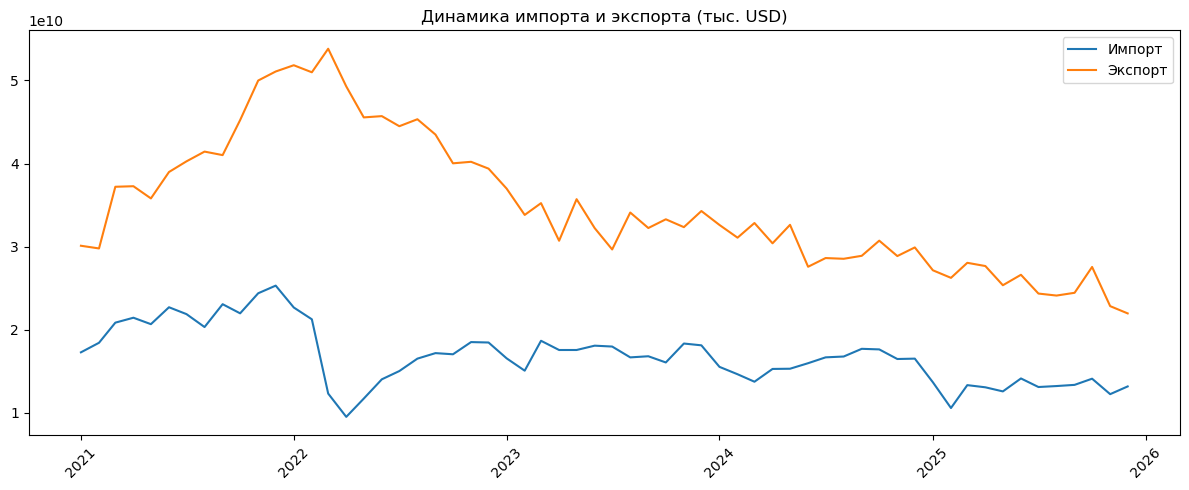

In [15]:
# Месячная динамика импорта и экспорта 2021–2025
dynamics = conn.execute("""
    SELECT 
        PERIOD,
        SUM(CASE WHEN NAPR = 'ИМ' THEN STOIM ELSE 0 END) as import_val,
        SUM(CASE WHEN NAPR = 'ЭК' THEN STOIM ELSE 0 END) as export_val
    FROM unified_trade_data
    WHERE PERIOD >= '2021-01-01'
    GROUP BY PERIOD
    ORDER BY PERIOD
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dynamics['PERIOD'], dynamics['import_val'], label='Импорт')
ax.plot(dynamics['PERIOD'], dynamics['export_val'], label='Экспорт')
ax.legend()
ax.set_title('Динамика импорта и экспорта (тыс. USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
import_2024 = conn.execute("""
    SELECT TNVED2, SUM(STOIM) as total
    FROM unified_trade_data
    WHERE PERIOD >= '2024-01-01' AND PERIOD < '2025-01-01'
      AND NAPR = 'ИМ' AND TNVED2 IS NOT NULL
    GROUP BY TNVED2
    ORDER BY total DESC
    LIMIT 10
""").df()

import_2025 = conn.execute("""
    SELECT TNVED2, SUM(STOIM) as total
    FROM unified_trade_data
    WHERE PERIOD >= '2025-01-01' AND PERIOD < '2026-01-01'
      AND NAPR = 'ИМ' AND TNVED2 IS NOT NULL
    GROUP BY TNVED2
    ORDER BY total DESC
    LIMIT 10
""").df()

print("Топ-10 TNVED2 по импорту 2024:\n", import_2024)
print("\nТоп-10 TNVED2 по импорту 2025:\n", import_2025)


Топ-10 TNVED2 по импорту 2024:
   TNVED2         total
0     84  3.579428e+10
1     87  2.891651e+10
2     85  1.995847e+10
3     30  1.156353e+10
4     39  7.146480e+09
5     90  6.895397e+09
6     29  5.113406e+09
7     08  4.307865e+09
8     64  3.918726e+09
9     61  3.647493e+09

Топ-10 TNVED2 по импорту 2025:
   TNVED2         total
0     84  3.130371e+10
1     85  1.736537e+10
2     87  1.522218e+10
3     30  9.724027e+09
4     90  6.139951e+09
5     39  5.410108e+09
6     29  4.367679e+09
7     98  4.103298e+09
8     73  3.405979e+09
9     64  3.374328e+09
